# SatQuery AI — Grounding Pipeline Starter

**Goal:** take a satellite image and produce structured, verifiable data (land-cover percentages) that the language layer can use to answer questions — instead of feeding raw pixels to an LLM and hoping it doesn't hallucinate.

**Approach:** no training needed. We use CLIP (a pretrained vision-language model) in **zero-shot** mode: split the image into a grid, and for each tile ask CLIP "which of these labels best matches this patch?" This gives us per-tile land-cover classification, which we aggregate into area percentages.

**Before running:** Runtime → Change runtime type → select a GPU (T4 is fine) → Save.

## 1. Install dependencies

In [ ]:
!pip install -q transformers torch pillow matplotlib requests open_clip_torch huggingface_hub

## 2. Load the CLIP model

This downloads a pretrained CLIP checkpoint (~600MB, one-time download per session).

In [ ]:
import torch
import open_clip
from huggingface_hub import hf_hub_download

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load standard CLIP architecture + preprocessing first
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

# Download and swap in the GeoRSCLIP weights (fine-tuned on satellite imagery)
ckpt_path = hf_hub_download(repo_id="Zilun/GeoRSCLIP", filename="ckpt/RS5M_ViT-B-32.pt")
checkpoint = torch.load(ckpt_path, map_location="cpu")
clip_model.load_state_dict(checkpoint, strict=False)

clip_model = clip_model.to(device).eval()
print("GeoRSCLIP model loaded.")

Using device: cuda
GeoRSCLIP model loaded.


## 3. Load a sample image

Option A: upload your own image (run the upload cell below).
Option B: use a placeholder URL — replace with an actual Bhuvan/sample satellite tile once your team has some.

Saving top-view-lake-mountain-satellite-260nw-2342966233.webp to top-view-lake-mountain-satellite-260nw-2342966233 (1).webp


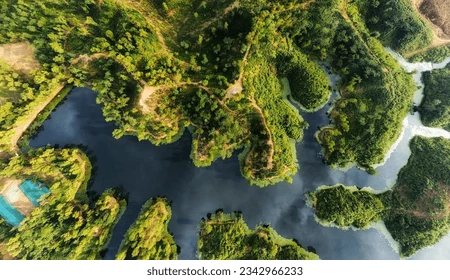

In [ ]:
# OPTION A: Upload an image from your computer
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()
image_filename = list(uploaded.keys())[0]
image = Image.open(io.BytesIO(uploaded[image_filename])).convert("RGB")
image

In [ ]:
# OPTION B (alternative to the upload cell above): load from a URL instead
# import requests
# from PIL import Image
# url = "PASTE_IMAGE_URL_HERE"
# image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
# image

## 4. Define land-cover labels and grid-classify the image

Adjust `CANDIDATE_LABELS` to match the categories your team actually wants to support. Keep the wording descriptive — CLIP performs better with fuller phrases than single words.

In [ ]:
CANDIDATE_LABELS = [
    "a satellite image of dense forest or vegetation",
    "a satellite image of a water body such as a river or lake",
    "a satellite image of urban or built-up area with buildings",
    "a satellite image of agricultural farmland",
    "a satellite image of barren or bare land",
    "a satellite image of a road or transportation network",
]

# Short class names used in the output JSON (must match order of CANDIDATE_LABELS above)
CLASS_NAMES = [
    "forest",
    "water_body",
    "urban_builtup",
    "agricultural_land",
    "barren_land",
    "road",
]

GRID_SIZE = 4  # 4x4 grid = 16 tiles. Increase for finer resolution, decrease for speed.

In [ ]:
def classify_tile(tile_image):
    """Run GeoRSCLIP zero-shot classification on a single image tile."""
    image_input = clip_preprocess(tile_image).unsqueeze(0).to(device)
    text_input = clip_tokenizer(CANDIDATE_LABELS).to(device)

    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)
        text_features = clip_model.encode_text(text_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        probs = (100.0 * image_features @ text_features.T).softmax(dim=-1).cpu().numpy()[0]

    best_idx = probs.argmax()
    return CLASS_NAMES[best_idx], float(probs[best_idx])


def grid_classify_image(image, grid_size=GRID_SIZE):
    """Split image into a grid_size x grid_size grid, classify each tile,
    and return a list of per-tile results with bounding box coordinates.
    """
    width, height = image.size
    tile_w = width // grid_size
    tile_h = height // grid_size

    results = []
    for row in range(grid_size):
        for col in range(grid_size):
            x_min = col * tile_w
            y_min = row * tile_h
            x_max = x_min + tile_w if col < grid_size - 1 else width
            y_max = y_min + tile_h if row < grid_size - 1 else height

            tile = image.crop((x_min, y_min, x_max, y_max))
            predicted_class, confidence = classify_tile(tile)

            results.append({
                "row": row,
                "col": col,
                "bbox": [x_min, y_min, x_max, y_max],
                "class": predicted_class,
                "confidence": round(confidence, 3)
            })
    return results


tile_results = grid_classify_image(image)
print(f"Classified {len(tile_results)} tiles.")
for t in tile_results[:5]:
    print(t)

Classified 16 tiles.
{'row': 0, 'col': 0, 'bbox': [0, 0, 112, 70], 'class': 'forest', 'confidence': 0.999}
{'row': 0, 'col': 1, 'bbox': [112, 0, 224, 70], 'class': 'forest', 'confidence': 1.0}
{'row': 0, 'col': 2, 'bbox': [224, 0, 336, 70], 'class': 'forest', 'confidence': 1.0}
{'row': 0, 'col': 3, 'bbox': [336, 0, 450, 70], 'class': 'forest', 'confidence': 0.941}
{'row': 1, 'col': 0, 'bbox': [0, 70, 112, 140], 'class': 'forest', 'confidence': 0.77}


## 5. Aggregate into structured JSON (matches `docs/api_contract.md` format)

In [ ]:
import json
from collections import defaultdict

def aggregate_to_grounding_json(tile_results, image_id="sample_001"):
    """Convert per-tile classification results into the aggregated
    detections format expected by the language layer.
    """
    class_tile_counts = defaultdict(int)
    class_confidences = defaultdict(list)

    for t in tile_results:
        class_tile_counts[t["class"]] += 1
        class_confidences[t["class"]].append(t["confidence"])

    total_tiles = len(tile_results)
    detections = []
    for class_name, count in class_tile_counts.items():
        area_percent = round((count / total_tiles) * 100, 1)
        avg_confidence = round(sum(class_confidences[class_name]) / len(class_confidences[class_name]), 3)
        detections.append({
            "class": class_name,
            "confidence": avg_confidence,
            "area_percent": area_percent,
            "bbox": None  # tile-grid based, not a single bounding box
        })

    # sort by area, largest first — makes it easier for the language layer to reason about
    detections.sort(key=lambda d: d["area_percent"], reverse=True)

    return {
        "image_id": image_id,
        "detections": detections
    }

grounding_output = aggregate_to_grounding_json(tile_results)
print(json.dumps(grounding_output, indent=2))

{
  "image_id": "sample_001",
  "detections": [
    {
      "class": "forest",
      "confidence": 0.908,
      "area_percent": 75.0,
      "bbox": null
    },
    {
      "class": "water_body",
      "confidence": 0.773,
      "area_percent": 25.0,
      "bbox": null
    }
  ]
}


## 6. Visualize — overlay the grid classification on the original image

This is what makes the answer "grounded" and demo-able — show the judges *why* the model said what it said.

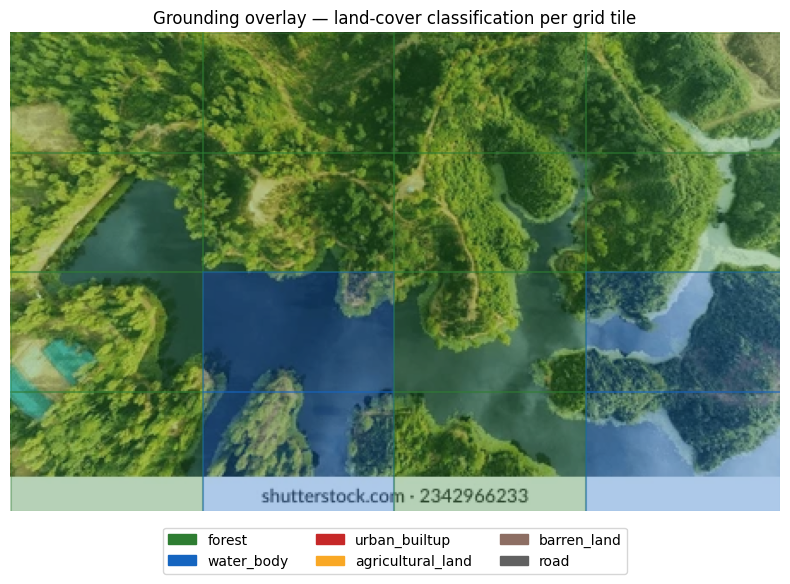

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CLASS_COLORS = {
    "forest": "#2e7d32",
    "water_body": "#1565c0",
    "urban_builtup": "#c62828",
    "agricultural_land": "#f9a825",
    "barren_land": "#8d6e63",
    "road": "#616161",
}

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(image)

for t in tile_results:
    x_min, y_min, x_max, y_max = t["bbox"]
    color = CLASS_COLORS.get(t["class"], "#ffffff")
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.35
    )
    ax.add_patch(rect)

ax.set_title("Grounding overlay — land-cover classification per grid tile")
ax.axis("off")

legend_patches = [patches.Patch(color=c, label=name) for name, c in CLASS_COLORS.items()]
ax.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=3)
plt.tight_layout()
plt.savefig("grounding_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save the output JSON

Download this and drop it in `grounding/outputs/` in the repo, or send it to whoever's working on the language layer so they can test against real data instead of mock data.

In [ ]:
output_filename = "grounding_output_sample_001.json"
with open(output_filename, "w") as f:
    json.dump(grounding_output, f, indent=2)

from google.colab import files
files.download(output_filename)
files.download("grounding_overlay.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Next steps for Member 1

- Test on several different sample images (varied terrain) to sanity-check the label set is actually distinguishing things well
- Tune `CANDIDATE_LABELS` wording if certain classes are consistently misclassified — CLIP is sensitive to phrasing
- Try increasing `GRID_SIZE` for finer resolution once basic version works, but note it slows down inference (more tiles = more CLIP calls)
- Stretch goal: add object counting (e.g. buildings) using a detection model like YOLOv8 alongside this classification step
- Once stable, turn this into a plain `.py` script in `grounding/` so the backend can call it directly instead of running it manually in Colab each time